# 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

#  2. Device

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


# 3. Load Dataset

In [3]:
df = pd.read_csv("robot_6dof_dataset_100000.csv")

print(df.head())
print(df.shape)


          x         y         z        qx        qy        qz        qw  \
0 -2.329131  0.901417  0.632726  0.304408 -0.811965  0.120671  0.483206   
1 -0.998224 -2.309097  0.706872 -0.176640 -0.021707 -0.743786  0.644290   
2 -3.080353  1.222846 -0.602774  0.377714  0.897657 -0.158633  0.162419   
3  1.331950  1.163471 -1.633395 -0.846923  0.122721  0.317182  0.408725   
4 -2.329253  0.739324  1.388622  0.243079  0.362487 -0.899188  0.031263   

           j1         j2          j3         j4         j5          j6  
0  177.277312  40.556323   -7.759785 -83.735354  60.892159  -15.149913  
1 -153.118978 -16.559584  -87.209377  27.210316  12.167601 -164.417519  
2  174.260438   4.588009   -2.062385  39.317751 -20.070234   14.442166  
3   58.129930  94.815914 -115.326219  23.616632 -18.430521 -130.522326  
4 -131.626688  28.456916  -51.113771  49.149088 -74.394015  112.140091  
(100000, 13)


# 4. Helper Functions

In [4]:
def encode_sincos(angles_deg):
    angles_rad = np.deg2rad(angles_deg)
    return np.concatenate([np.sin(angles_rad), np.cos(angles_rad)], axis=1)


def sincos_to_angles_deg(y_pred):
    sin_vals = y_pred[:, : y_pred.shape[1] // 2]
    cos_vals = y_pred[:, y_pred.shape[1] // 2 :]

    angles_rad = np.arctan2(sin_vals, cos_vals)
    return np.rad2deg(angles_rad)


def angular_error_deg(pred, true):
    return np.abs((pred - true + 180) % 360 - 180)


# 5. Prepare Data

In [5]:
positions = df[["x", "y", "z"]].values
quaternions = df[["qx", "qy", "qz", "qw"]].values

angles = df[["j1", "j2", "j3", "j4", "j5", "j6"]].values

arm_angles = angles[:, :3]
wrist_angles = angles[:, 3:]

np.random.seed(42)

arm_noise = np.random.normal(0, 40, size=arm_angles.shape)
wrist_noise = np.random.normal(0, 40, size=wrist_angles.shape)

seed_arm = arm_angles + arm_noise
seed_wrist = wrist_angles + wrist_noise

arm_mins = np.array([-180, -20, -120])
arm_maxs = np.array([180, 140, 0])

wrist_mins = np.array([-90, -90, -180])
wrist_maxs = np.array([90, 90, 180])

seed_arm = np.clip(seed_arm, arm_mins, arm_maxs)
seed_wrist = np.clip(seed_wrist, wrist_mins, wrist_maxs)

X_arm = np.concatenate([positions, seed_arm], axis=1)
y_arm = encode_sincos(arm_angles)

X_wrist = np.concatenate([quaternions, arm_angles, seed_wrist], axis=1)
y_wrist = encode_sincos(wrist_angles)

print("X_arm:", X_arm.shape)
print("y_arm:", y_arm.shape)

print("X_wrist:", X_wrist.shape)
print("y_wrist:", y_wrist.shape)


X_arm: (100000, 6)
y_arm: (100000, 6)
X_wrist: (100000, 10)
y_wrist: (100000, 6)


# 6. Train/Val/Test Split

In [6]:
X_arm_train, X_arm_temp, y_arm_train, y_arm_temp, arm_train, arm_temp = (
    train_test_split(X_arm, y_arm, arm_angles, test_size=0.30, random_state=42)
)

X_arm_val, X_arm_test, y_arm_val, y_arm_test, arm_val, arm_test = train_test_split(
    X_arm_temp, y_arm_temp, arm_temp, test_size=0.50, random_state=42
)

X_wrist_train, X_wrist_temp, y_wrist_train, y_wrist_temp, wrist_train, wrist_temp = (
    train_test_split(X_wrist, y_wrist, wrist_angles, test_size=0.30, random_state=42)
)

X_wrist_val, X_wrist_test, y_wrist_val, y_wrist_test, wrist_val, wrist_test = (
    train_test_split(
        X_wrist_temp, y_wrist_temp, wrist_temp, test_size=0.50, random_state=42
    )
)

print("Arm train/val/test:", len(X_arm_train), len(X_arm_val), len(X_arm_test))
print("Wrist train/val/test:", len(X_wrist_train), len(X_wrist_val), len(X_wrist_test))


Arm train/val/test: 70000 15000 15000
Wrist train/val/test: 70000 15000 15000


# 7. Scale Inputs

In [7]:
arm_scaler = StandardScaler()
wrist_scaler = StandardScaler()

X_arm_train_s = arm_scaler.fit_transform(X_arm_train)
X_arm_val_s = arm_scaler.transform(X_arm_val)
X_arm_test_s = arm_scaler.transform(X_arm_test)

X_wrist_train_s = wrist_scaler.fit_transform(X_wrist_train)
X_wrist_val_s = wrist_scaler.transform(X_wrist_val)
X_wrist_test_s = wrist_scaler.transform(X_wrist_test)


# 8. Convert to Tensors

In [8]:
def to_tensor(x):
    return torch.tensor(x, dtype=torch.float32).to(device)


X_arm_train_t = to_tensor(X_arm_train_s)
y_arm_train_t = to_tensor(y_arm_train)
X_arm_val_t = to_tensor(X_arm_val_s)
y_arm_val_t = to_tensor(y_arm_val)
X_arm_test_t = to_tensor(X_arm_test_s)
y_arm_test_t = to_tensor(y_arm_test)

X_wrist_train_t = to_tensor(X_wrist_train_s)
y_wrist_train_t = to_tensor(y_wrist_train)
X_wrist_val_t = to_tensor(X_wrist_val_s)
y_wrist_val_t = to_tensor(y_wrist_val)
X_wrist_test_t = to_tensor(X_wrist_test_s)
y_wrist_test_t = to_tensor(y_wrist_test)


# 9. DataLoaders

In [9]:
batch_size = 256

arm_train_loader = DataLoader(
    TensorDataset(X_arm_train_t, y_arm_train_t), batch_size=batch_size, shuffle=True
)

wrist_train_loader = DataLoader(
    TensorDataset(X_wrist_train_t, y_wrist_train_t), batch_size=batch_size, shuffle=True
)


# 10. Model Class

In [10]:
class IKSubNet(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim),
        )

    def forward(self, x):
        return self.net(x)


# 11. Training Function

In [11]:
def train_model(
    model, train_loader, X_val_t, y_val_t, save_path, epochs=200, patience=20, lr=1e-3
):
    model = model.to(device)

    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=8, factor=0.5
    )

    train_losses = []
    val_losses = []

    best_val_loss = float("inf")
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        batch_losses = []

        for xb, yb in train_loader:
            optimizer.zero_grad()

            preds = model(xb)
            loss = loss_fn(preds, yb)

            loss.backward()
            optimizer.step()

            batch_losses.append(loss.item())

        train_loss = np.mean(batch_losses)

        model.eval()
        with torch.no_grad():
            val_preds = model(X_val_t)
            val_loss = loss_fn(val_preds, y_val_t).item()

        scheduler.step(val_loss)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
        else:
            patience_counter += 1

        if epoch % 10 == 0:
            print(
                f"Epoch {epoch:03d} | "
                f"Train Loss: {train_loss:.6f} | "
                f"Val Loss: {val_loss:.6f}"
            )

        if patience_counter >= patience:
            print("Early stopping")
            break

    print("Best validation loss:", best_val_loss)

    return train_losses, val_losses


# 12. Train Arm Model

In [12]:
arm_model = IKSubNet(input_dim=6, output_dim=6).to(device)

arm_train_losses, arm_val_losses = train_model(
    model=arm_model,
    train_loader=arm_train_loader,
    X_val_t=X_arm_val_t,
    y_val_t=y_arm_val_t,
    save_path="best_arm_position_model.pth",
    epochs=200,
    patience=25,
    lr=1e-3,
)


Epoch 000 | Train Loss: 0.076125 | Val Loss: 0.057969
Epoch 010 | Train Loss: 0.057025 | Val Loss: 0.053819
Epoch 020 | Train Loss: 0.055301 | Val Loss: 0.052369
Epoch 030 | Train Loss: 0.054407 | Val Loss: 0.052193
Epoch 040 | Train Loss: 0.053898 | Val Loss: 0.052368
Epoch 050 | Train Loss: 0.053699 | Val Loss: 0.052089
Epoch 060 | Train Loss: 0.052232 | Val Loss: 0.051022
Epoch 070 | Train Loss: 0.051830 | Val Loss: 0.050875
Epoch 080 | Train Loss: 0.051140 | Val Loss: 0.050271
Epoch 090 | Train Loss: 0.050571 | Val Loss: 0.050249
Epoch 100 | Train Loss: 0.050529 | Val Loss: 0.050155
Epoch 110 | Train Loss: 0.049963 | Val Loss: 0.050116
Epoch 120 | Train Loss: 0.049918 | Val Loss: 0.050181
Epoch 130 | Train Loss: 0.049771 | Val Loss: 0.050193
Epoch 140 | Train Loss: 0.049899 | Val Loss: 0.050269
Epoch 150 | Train Loss: 0.049589 | Val Loss: 0.050098
Epoch 160 | Train Loss: 0.049668 | Val Loss: 0.050142
Epoch 170 | Train Loss: 0.049375 | Val Loss: 0.050113
Epoch 180 | Train Loss: 0.04

# 13. Train Wrist Model

In [13]:
wrist_model = IKSubNet(input_dim=10, output_dim=6).to(device)

wrist_train_losses, wrist_val_losses = train_model(
    model=wrist_model,
    train_loader=wrist_train_loader,
    X_val_t=X_wrist_val_t,
    y_val_t=y_wrist_val_t,
    save_path="best_wrist_orientation_model.pth",
    epochs=200,
    patience=25,
    lr=1e-3,
)


Epoch 000 | Train Loss: 0.104356 | Val Loss: 0.045399
Epoch 010 | Train Loss: 0.032059 | Val Loss: 0.017442
Epoch 020 | Train Loss: 0.028421 | Val Loss: 0.015906
Epoch 030 | Train Loss: 0.026017 | Val Loss: 0.014368
Epoch 040 | Train Loss: 0.024678 | Val Loss: 0.013085
Epoch 050 | Train Loss: 0.023369 | Val Loss: 0.011594
Epoch 060 | Train Loss: 0.022302 | Val Loss: 0.011897
Epoch 070 | Train Loss: 0.022398 | Val Loss: 0.011751
Epoch 080 | Train Loss: 0.022170 | Val Loss: 0.011281
Epoch 090 | Train Loss: 0.020319 | Val Loss: 0.010627
Epoch 100 | Train Loss: 0.019978 | Val Loss: 0.010355
Epoch 110 | Train Loss: 0.019561 | Val Loss: 0.009700
Epoch 120 | Train Loss: 0.018922 | Val Loss: 0.009691
Epoch 130 | Train Loss: 0.019125 | Val Loss: 0.009668
Epoch 140 | Train Loss: 0.018497 | Val Loss: 0.009374
Epoch 150 | Train Loss: 0.018196 | Val Loss: 0.009511
Epoch 160 | Train Loss: 0.018776 | Val Loss: 0.009493
Early stopping
Best validation loss: 0.009247587993741035


# 14. Plot Losses

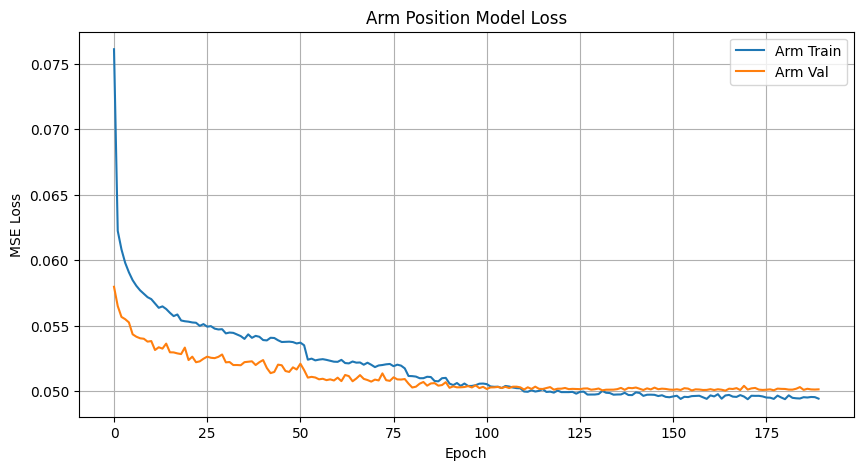

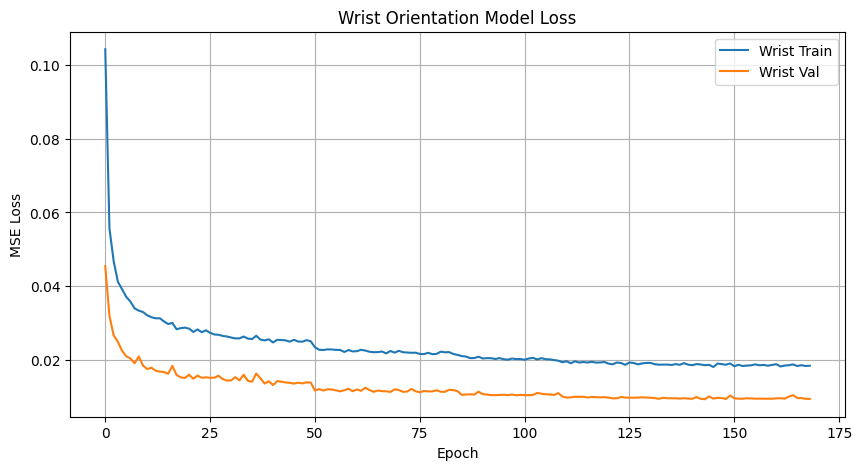

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(arm_train_losses, label="Arm Train")
plt.plot(arm_val_losses, label="Arm Val")
plt.title("Arm Position Model Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(wrist_train_losses, label="Wrist Train")
plt.plot(wrist_val_losses, label="Wrist Val")
plt.title("Wrist Orientation Model Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()


# 15. Evaluate Arm Model

In [15]:
arm_model.load_state_dict(
    torch.load("best_arm_position_model.pth", map_location=device)
)
arm_model.eval()

loss_fn = nn.MSELoss()

with torch.no_grad():
    arm_preds_sincos = arm_model(X_arm_test_t)
    arm_test_loss = loss_fn(arm_preds_sincos, y_arm_test_t)

print("Arm sincos test loss:", arm_test_loss.item())

arm_preds = arm_preds_sincos.cpu().numpy()
arm_pred_angles = sincos_to_angles_deg(arm_preds)

arm_errors = angular_error_deg(arm_pred_angles, arm_test)

for i in range(3):
    print(f"Arm Joint {i + 1} MAE: {arm_errors[:, i].mean():.3f} degrees")
    print(f"Arm Joint {i + 1} Max Error: {arm_errors[:, i].max():.3f} degrees")
    print()

print("Arm Overall MAE:", arm_errors.mean())


Arm sincos test loss: 0.05058717355132103
Arm Joint 1 MAE: 16.736 degrees
Arm Joint 1 Max Error: 174.244 degrees

Arm Joint 2 MAE: 10.516 degrees
Arm Joint 2 Max Error: 80.520 degrees

Arm Joint 3 MAE: 15.856 degrees
Arm Joint 3 Max Error: 75.291 degrees

Arm Overall MAE: 14.369535070135893


C:\Users\shivo\AppData\Local\Temp\ipykernel_10744\1575107435.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load("best_arm_position_model.pth", map_location=devic

# 16. Evaluate Wrist Model

In [20]:
wrist_model.load_state_dict(
    torch.load("best_wrist_orientation_model.pth", map_location=device)
)
wrist_model.eval()

with torch.no_grad():
    wrist_preds_sincos = wrist_model(X_wrist_test_t)
    wrist_test_loss = loss_fn(wrist_preds_sincos, y_wrist_test_t)

print("Wrist sincos test loss:", wrist_test_loss.item())

wrist_preds = wrist_preds_sincos.cpu().numpy()
wrist_pred_angles = sincos_to_angles_deg(wrist_preds)

wrist_errors = angular_error_deg(wrist_pred_angles, wrist_test)

for i in range(3):
    print(f"Wrist Joint {i + 4} MAE: {wrist_errors[:, i].mean():.3f} degrees")
    print(f"Wrist Joint {i + 4} Max Error: {wrist_errors[:, i].max():.3f} degrees")
    print()

print("Wrist Overall MAE:", wrist_errors.mean())


Wrist sincos test loss: 0.00919985119253397
Wrist Joint 4 MAE: 5.785 degrees
Wrist Joint 4 Max Error: 94.172 degrees

Wrist Joint 5 MAE: 2.384 degrees
Wrist Joint 5 Max Error: 16.520 degrees

Wrist Joint 6 MAE: 5.752 degrees
Wrist Joint 6 Max Error: 86.390 degrees

Wrist Overall MAE: 4.640325023789088


C:\Users\shivo\AppData\Local\Temp\ipykernel_10744\2002425368.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load("best_wrist_orientation_model.pth", map_location=

# 17. Python FK

In [21]:
ROBOT = {
    "BASE_HEIGHT": 0.25,
    "UPPER_ARM_LENGTH": 1.2,
    "FOREARM_LENGTH": 1.0,
    "WRIST_LENGTH": 0.45,
    "TOOL_LENGTH": 0.35,
    "TCP_OFFSET": 0.5,
}


def rot_x(a):
    c, s = np.cos(a), np.sin(a)
    return np.array(
        [
            [1, 0, 0, 0],
            [0, c, -s, 0],
            [0, s, c, 0],
            [0, 0, 0, 1],
        ]
    )


def rot_y(a):
    c, s = np.cos(a), np.sin(a)
    return np.array(
        [
            [c, 0, s, 0],
            [0, 1, 0, 0],
            [-s, 0, c, 0],
            [0, 0, 0, 1],
        ]
    )


def rot_z(a):
    c, s = np.cos(a), np.sin(a)
    return np.array(
        [
            [c, -s, 0, 0],
            [s, c, 0, 0],
            [0, 0, 1, 0],
            [0, 0, 0, 1],
        ]
    )


def trans(x, y, z):
    T = np.eye(4)
    T[:3, 3] = [x, y, z]
    return T


def fk_python(joint_angles_deg):
    j1, j2, j3, j4, j5, j6 = np.deg2rad(joint_angles_deg)

    T = np.eye(4)

    T = T @ trans(0, ROBOT["BASE_HEIGHT"], 0)
    T = T @ rot_y(j1)
    T = T @ rot_z(j2)
    T = T @ trans(ROBOT["UPPER_ARM_LENGTH"], 0, 0)
    T = T @ rot_z(j3)
    T = T @ trans(ROBOT["FOREARM_LENGTH"], 0, 0)
    T = T @ rot_z(j4)
    T = T @ trans(ROBOT["WRIST_LENGTH"], 0, 0)
    T = T @ rot_y(j5)
    T = T @ trans(ROBOT["TOOL_LENGTH"], 0, 0)
    T = T @ rot_x(j6)
    T = T @ trans(ROBOT["TCP_OFFSET"], 0, 0)

    return T[:3, 3], T[:3, :3]


# 18. Quaternion Helpers

In [22]:
def rotation_matrix_to_quaternion(R):
    q = np.empty(4)
    trace = np.trace(R)

    if trace > 0:
        s = 0.5 / np.sqrt(trace + 1.0)
        q[3] = 0.25 / s
        q[0] = (R[2, 1] - R[1, 2]) * s
        q[1] = (R[0, 2] - R[2, 0]) * s
        q[2] = (R[1, 0] - R[0, 1]) * s
    else:
        if R[0, 0] > R[1, 1] and R[0, 0] > R[2, 2]:
            s = 2.0 * np.sqrt(1.0 + R[0, 0] - R[1, 1] - R[2, 2])
            q[3] = (R[2, 1] - R[1, 2]) / s
            q[0] = 0.25 * s
            q[1] = (R[0, 1] + R[1, 0]) / s
            q[2] = (R[0, 2] + R[2, 0]) / s
        elif R[1, 1] > R[2, 2]:
            s = 2.0 * np.sqrt(1.0 + R[1, 1] - R[0, 0] - R[2, 2])
            q[3] = (R[0, 2] - R[2, 0]) / s
            q[0] = (R[0, 1] + R[1, 0]) / s
            q[1] = 0.25 * s
            q[2] = (R[1, 2] + R[2, 1]) / s
        else:
            s = 2.0 * np.sqrt(1.0 + R[2, 2] - R[0, 0] - R[1, 1])
            q[3] = (R[1, 0] - R[0, 1]) / s
            q[0] = (R[0, 2] + R[2, 0]) / s
            q[1] = (R[1, 2] + R[2, 1]) / s
            q[2] = 0.25 * s

    if q[3] < 0:
        q = -q

    return q


def quaternion_error_rad(q_pred, q_true):
    dot = np.abs(np.dot(q_pred, q_true))
    dot = np.clip(dot, -1.0, 1.0)
    return 2 * np.arccos(dot)


# 19. Combined Split-Model FK Evaluation

In [23]:
# Important:
# For fair combined evaluation, use matching rows from the original dataset.
# Here we evaluate using the first N test examples from arm test data.

N = len(X_arm_test)

combined_pred_angles = []

target_positions = X_arm_test[:, :3]

# For target quaternions, use matching original dataframe rows is complicated after separate splits.
# So this combined FK eval focuses on position first.
# Later we can make a unified split for perfect pose+orientation evaluation.

for i in range(N):
    pos = X_arm_test[i, :3]
    seed_arm_i = X_arm_test[i, 3:6]

    arm_input = np.concatenate([pos, seed_arm_i]).reshape(1, -1)
    arm_input_s = arm_scaler.transform(arm_input)

    with torch.no_grad():
        arm_out = (
            arm_model(torch.tensor(arm_input_s, dtype=torch.float32).to(device))
            .cpu()
            .numpy()
        )

    pred_arm = sincos_to_angles_deg(arm_out)[0]

    # Use true quaternion from closest matching original row not available here,
    # so for now use wrist model test split independently.
    # Quick combined placeholder:
    pred_wrist = wrist_pred_angles[i % len(wrist_pred_angles)]

    full_angles = np.concatenate([pred_arm, pred_wrist])
    combined_pred_angles.append(full_angles)

combined_pred_angles = np.array(combined_pred_angles)

position_errors = []

for i in range(N):
    pred_pos, _ = fk_python(combined_pred_angles[i])
    pos_error = np.linalg.norm(pred_pos - target_positions[i])
    position_errors.append(pos_error)

position_errors = np.array(position_errors)

print("Split Model FK Position Error")
print("Mean:", position_errors.mean())
print("Median:", np.median(position_errors))
print("Max:", position_errors.max())


Split Model FK Position Error
Mean: 0.720505862028891
Median: 0.6915381534828062
Max: 3.6630888967498407


# 20. Better Unified Split for Final Evaluation

In [24]:
# This is better than the placeholder above.
# We create one unified test set so position, quaternion, and true angles stay aligned.

full_pose = np.concatenate([positions, quaternions], axis=1)

full_X = np.concatenate([positions, quaternions, seed_arm, seed_wrist], axis=1)

full_train, full_temp, angles_full_train, angles_full_temp = train_test_split(
    full_X, angles, test_size=0.30, random_state=42
)

full_val, full_test, angles_full_val, angles_full_test = train_test_split(
    full_temp, angles_full_temp, test_size=0.50, random_state=42
)

print(full_test.shape)
print(angles_full_test.shape)


(15000, 13)
(15000, 6)


# 21. Final Split-Model Task-Space Evaluation

In [25]:
position_errors = []
orientation_errors = []

for i in range(len(full_test)):
    row = full_test[i]

    target_pos = row[:3]
    target_quat = row[3:7]
    seed_arm_i = row[7:10]
    seed_wrist_i = row[10:13]

    arm_input = np.concatenate([target_pos, seed_arm_i]).reshape(1, -1)
    arm_input_s = arm_scaler.transform(arm_input)

    with torch.no_grad():
        arm_out = (
            arm_model(torch.tensor(arm_input_s, dtype=torch.float32).to(device))
            .cpu()
            .numpy()
        )

    pred_arm = sincos_to_angles_deg(arm_out)[0]

    wrist_input = np.concatenate([target_quat, pred_arm, seed_wrist_i]).reshape(1, -1)

    wrist_input_s = wrist_scaler.transform(wrist_input)

    with torch.no_grad():
        wrist_out = (
            wrist_model(torch.tensor(wrist_input_s, dtype=torch.float32).to(device))
            .cpu()
            .numpy()
        )

    pred_wrist = sincos_to_angles_deg(wrist_out)[0]

    pred_full_angles = np.concatenate([pred_arm, pred_wrist])

    pred_pos, pred_rot = fk_python(pred_full_angles)
    pred_quat = rotation_matrix_to_quaternion(pred_rot)

    position_errors.append(np.linalg.norm(pred_pos - target_pos))
    orientation_errors.append(quaternion_error_rad(pred_quat, target_quat))

position_errors = np.array(position_errors)
orientation_errors = np.array(orientation_errors)

print("Final Split Model FK Position Error")
print("Mean:", position_errors.mean())
print("Median:", np.median(position_errors))
print("Max:", position_errors.max())

print("\nFinal Split Model FK Orientation Error")
print("Mean radians:", orientation_errors.mean())
print("Median radians:", np.median(orientation_errors))
print("Mean degrees:", np.rad2deg(orientation_errors.mean()))
print("Median degrees:", np.rad2deg(np.median(orientation_errors)))
print("Max degrees:", np.rad2deg(orientation_errors.max()))
  

Final Split Model FK Position Error
Mean: 0.5591792686556568
Median: 0.531839789037322
Max: 3.474632365007413

Final Split Model FK Orientation Error
Mean radians: 0.11609655286747517
Median radians: 0.0870541387964385
Mean degrees: 6.651842495323763
Median degrees: 4.987834742182006
Max degrees: 162.89280788780832


# 22. Single Prediction Test

In [26]:
sample_index = 0

row = full_test[sample_index]

target_pos = row[:3]
target_quat = row[3:7]
seed_arm_i = row[7:10]
seed_wrist_i = row[10:13]

true_angles = angles_full_test[sample_index]

arm_input = np.concatenate([target_pos, seed_arm_i]).reshape(1, -1)
arm_input_s = arm_scaler.transform(arm_input)

with torch.no_grad():
    arm_out = (
        arm_model(torch.tensor(arm_input_s, dtype=torch.float32).to(device))
        .cpu()
        .numpy()
    )

pred_arm = sincos_to_angles_deg(arm_out)[0]

wrist_input = np.concatenate([target_quat, pred_arm, seed_wrist_i]).reshape(1, -1)

wrist_input_s = wrist_scaler.transform(wrist_input)

with torch.no_grad():
    wrist_out = (
        wrist_model(torch.tensor(wrist_input_s, dtype=torch.float32).to(device))
        .cpu()
        .numpy()
    )

pred_wrist = sincos_to_angles_deg(wrist_out)[0]

pred_full_angles = np.concatenate([pred_arm, pred_wrist])

print("Target position:")
print(target_pos)

print("\nTarget quaternion:")
print(target_quat)

print("\nSeed arm:")
print(seed_arm_i)

print("\nSeed wrist:")
print(seed_wrist_i)

print("\nTrue angles:")
print(true_angles)

print("\nPredicted angles:")
print(pred_full_angles)

print("\nCircular angle error:")
print(angular_error_deg(pred_full_angles.reshape(1, -1), true_angles.reshape(1, -1))[0])

pred_pos, pred_rot = fk_python(pred_full_angles)
pred_quat = rotation_matrix_to_quaternion(pred_rot)

print("\nPredicted FK position:")
print(pred_pos)

print("\nPosition error:")
print(np.linalg.norm(pred_pos - target_pos))

print("\nOrientation error degrees:")
print(np.rad2deg(quaternion_error_rad(pred_quat, target_quat)))


Target position:
[ 0.85728461  2.73000538 -0.07349839]

Target quaternion:
[ 0.90441709  0.19578697 -0.08298013  0.36988038]

Seed arm:
[169.95716006 128.9795224  -56.48114267]

Seed wrist:
[ 90.         -90.           8.70511977]

True angles:
[115.40461253 121.57598574 -68.98156081  60.32714525 -71.46648949
  18.76684913]

Predicted angles:
[131.22203  123.54375  -47.375072  69.22569  -63.88513  -16.632425]

Circular angle error:
[15.81741811  1.96776121 21.60648833  8.8985475   7.58135765 35.39927444]

Predicted FK position:
[1.30050335 2.68921361 0.32620517]

Position error:
0.5982221633674889

Orientation error degrees:
2.960210464079412


# 23. Save Models

In [27]:
torch.save(arm_model.state_dict(), "arm_position_model.pth")
torch.save(wrist_model.state_dict(), "wrist_orientation_model.pth")

joblib.dump(arm_scaler, "arm_scaler.pkl")
joblib.dump(wrist_scaler, "wrist_scaler.pkl")

print("Saved:")
print("arm_position_model.pth")
print("wrist_orientation_model.pth")
print("arm_scaler.pkl")
print("wrist_scaler.pkl")


Saved:
arm_position_model.pth
wrist_orientation_model.pth
arm_scaler.pkl
wrist_scaler.pkl
